# 02_Core_Concepts.ipynb

---

# Working Intuition

Before understanding the mathematics, it's important to build an intuition for **what Ridge Regression is actually doing**.

Suppose you're predicting house prices.

Your Linear Regression model learns:

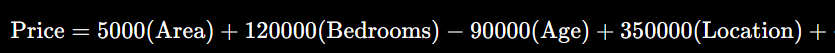

Some coefficients become **very large**.

Large coefficients mean:

* The model depends heavily on certain features.
* Small changes in those features can cause large changes in predictions.
* The model becomes sensitive to noise.
* It may fit the training data too closely (overfitting).

---

## Why are Large Coefficients a Problem?

Imagine fitting a line through noisy data.

### Dataset

```
Area (sq.ft)     Price
1000             40
1200             48
1500             61
1700             69
2000             79
```

Now suppose one training example has an incorrect price:

```
1700 → 100 (instead of 69)
```

Ordinary Linear Regression tries very hard to fit this noisy point.

As a result:

* Slope becomes steeper.
* Coefficients increase.
* Future predictions become worse.

---

## Ridge Regression's Idea

Instead of asking

> "How can I reduce training error as much as possible?"

Ridge asks

> "Can I reduce training error **without making coefficients too large**?"

It prefers a slightly less accurate training fit if that leads to better performance on unseen data.

---

## The Tug-of-War

Think of Ridge Regression as balancing two competing objectives.

```
             Ridge Regression

     Prediction Error
            ▲
            │
            │
            │
            ●  Best Balance
            │
            │
            ▼
    Small Coefficients
```

The algorithm searches for a balance between:

* fitting the data well
* keeping coefficients small

---

## What Does "Shrink Coefficients" Mean?

Suppose Linear Regression learns:

| Feature  | Coefficient |
| -------- | ----------: |
| Area     |         7.2 |
| Bedrooms |         5.8 |
| Age      |        -3.1 |
| Distance |        -6.4 |

Ridge might learn:

| Feature  | Coefficient |
| -------- | ----------: |
| Area     |         5.9 |
| Bedrooms |         4.4 |
| Age      |        -2.3 |
| Distance |        -4.8 |

Notice:

* Signs usually stay the same.
* Magnitudes become smaller.
* No coefficient becomes exactly zero.

---

## Why Does Smaller Mean Better?

Large coefficients usually indicate that the model is trying to fit every tiny fluctuation in the training data.

Smaller coefficients make the model:

* smoother
* more stable
* less sensitive to noise
* better at generalizing

---

## Bias-Variance Trade-off

Ridge intentionally introduces a **small amount of bias** to significantly reduce **variance**.

```
Without Ridge

High Variance
Low Bias

↓

With Ridge

Slightly Higher Bias
Much Lower Variance
```

In practice, reducing variance often improves test performance more than the slight increase in bias hurts it.

---

# Important Terminology

---

## 1. Regularization

Regularization is a technique used to prevent overfitting by penalizing complex models.

Ridge uses **L2 Regularization**.

---

## 2. Coefficient (Weight)

The number multiplied by each feature.

Example:

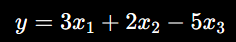

Coefficients are:

* 3
* 2
* -5

Ridge tries to keep these values small.

---

## 3. Penalty

The extra cost added to the loss function.

The larger the coefficients become, the larger the penalty becomes.

---

## 4. L2 Regularization

Ridge penalizes the **sum of squared coefficients**.

Conceptually:

```
Penalty = (Coefficient₁² + Coefficient₂² + ...)
```

Important characteristics:

* squares every coefficient
* ignores the sign (positive/negative)
* penalizes larger values much more strongly than smaller ones

---

## 5. Alpha (α)

The regularization strength.

It controls how strongly coefficients are shrunk.

Small α:

```
Almost Linear Regression
```

Large α:

```
Strong regularization
```

Very large α:

```
Underfitting
```

---

## 6. Shrinkage

Reducing coefficient magnitudes toward zero.

Example:

```
Before Ridge

8.5
5.2
-6.3
2.7
```

↓

```
After Ridge

5.4
3.8
-4.1
1.9
```

They become **smaller**, but usually **not zero**.

---

## 7. Overfitting

The model memorizes the training data, including noise.

Characteristics:

* Very low training error
* High testing error

---

## 8. Underfitting

The model is too simple to capture the underlying pattern.

Characteristics:

* High training error
* High testing error

---

## 9. Multicollinearity

Occurs when two or more input features are highly correlated.

Example:

```
Height (cm)
Height (inch)
```

or

```
Salary
Annual Income
```

Linear Regression may produce unstable coefficients.

Ridge stabilizes them by shrinking all coefficients.

---

# Assumptions

Ridge Regression inherits the assumptions of Linear Regression.

---

## 1. Linear Relationship

The relationship between features and the target should be approximately linear.

Example:

```
Price ≈ Area
```

Good.

If the true relationship is highly nonlinear, Ridge alone may not perform well.

---

## 2. Independence of Observations

Each training example should be independent of the others.

Example:

Different customers' purchase records are typically independent.

---

## 3. Constant Variance (Homoscedasticity)

The variance of the errors should remain roughly constant across predictions.

Good:

```
•
 •
  •
 •
•
```

Bad (variance increases):

```
•
 •
   •
      •
          •
```

---

## 4. Errors Should Be Approximately Normally Distributed

Especially useful for statistical inference (confidence intervals, hypothesis testing).

For pure prediction, this assumption is less critical.

---

## 5. Features Should Be Scaled

This assumption is **especially important for Ridge Regression**.

Example:

```
Age = 25

Income = 8,00,000
```

Without scaling:

Income dominates the penalty because its values are much larger.

Use:

* `StandardScaler`
* `MinMaxScaler` (less common for Ridge)

Standardization is generally preferred.

---

# Types / Variants (if applicable)

Ridge Regression itself has a few practical variants based on the solver used.

---

## 1. Closed-Form Ridge

Uses a direct mathematical solution.

Characteristics:

* Exact solution
* Fast for small to medium datasets
* No iterative optimization required

---

## 2. Gradient Descent Ridge

Updates coefficients iteratively.

Useful for:

* large datasets
* custom implementations
* learning purposes

---

## 3. Stochastic Gradient Descent (SGD)

Updates after every training example.

Useful for:

* extremely large datasets
* online learning

Implemented in scikit-learn using `SGDRegressor` with L2 penalty.

---

# Decision Boundary / Model Behavior

Ridge Regression is a **regression algorithm**, so it does **not** have a decision boundary like classification algorithms.

Instead, it learns a **prediction function**.

For one feature:

```
Price
 ^
 |
 |      /
 |     /
 |    /
 |   /
 +------------------> Area
```

Compared to Linear Regression, Ridge often produces a slightly "flatter" line because the coefficients are smaller.

---

### Model Behavior as α Changes

```
α = 0

Almost identical to Linear Regression
```

↓

```
α = 1

Small coefficient shrinkage
```

↓

```
α = 10

Noticeable shrinkage
```

↓

```
α = 1000

Nearly flat line
```

↓

```
Extreme underfitting
```

---

# Advantages & Disadvantages

## Advantages

### Reduces overfitting

Especially useful on noisy datasets.

---

### Handles multicollinearity well

Produces more stable coefficient estimates when features are highly correlated.

---

### Uses all available features

Unlike Lasso, no feature is discarded.

---

### Convex optimization

There is a single global optimum, making optimization reliable.

---

### Stable predictions

Less sensitive to small changes in the training data.

---

## Disadvantages

### No feature selection

All features remain in the model.

---

### Requires feature scaling

Without scaling, the penalty becomes uneven across features.

---

### Introduces bias

The model sacrifices a bit of training accuracy to improve generalization.

---

### Still assumes linearity

Cannot capture complex nonlinear relationships on its own.

---

# When To Use / Avoid

## Use Ridge Regression When

* You have many features.
* Features are highly correlated (multicollinearity).
* Linear Regression is overfitting.
* You want to keep **all** features in the model.
* Prediction accuracy is more important than coefficient interpretability.

---

## Avoid Ridge Regression When

* You need automatic feature selection (prefer **Lasso Regression**).
* The relationship is strongly nonlinear (consider Decision Trees, Random Forests, Gradient Boosting, etc.).
* The dataset is extremely small and simple, where ordinary Linear Regression already performs well.
* Your features are not scaled and you cannot preprocess them appropriately.

---

# Key Takeaways

* Ridge Regression extends Linear Regression using **L2 Regularization**.
* Its core idea is to **balance prediction accuracy with smaller coefficients**.
* The main hyperparameter is **α (alpha)**, which controls the amount of regularization.
* Ridge **shrinks** coefficients but **does not remove** features.
* It is particularly effective when dealing with **overfitting** and **multicollinearity**.
* **Feature scaling is essential** before applying Ridge Regression.

---